# **Deep Learning-Based Real vs Fake Face Detection**

## **Deepfake Image Detection using CNN and Transfer Learning**

### **Introduction**

Today, technology is growing very fast, especially in artificial intelligence. Because of this, it is now possible to create fake human face images that look very real. These fake images are called deepfakes. It is often very difficult to tell the difference between real and fake faces.

Fake images can be used in harmful ways, such as spreading false information, creating fake identities, and misusing digital content. So, detecting real and fake faces has become very important.

In this project, we use deep learning to identify whether a face image is real or fake. For this, we use the dataset “140K Real and Fake Faces” from Kaggle. The main aim of this project is to build a model that can correctly classify images and help improve digital security.

### **Objective**

The main objective of this project is to build a deep learning system that can identify whether a face image is real or fake. The system uses techniques like CNN (Convolutional Neural Networks) and transfer learning to understand the patterns in fake images.


1.   Build a basic CNN model to classify real and fake images.

1.   Use transfer learning with MobileNetV2 to improve the model.

1.   Compare the performance of the CNN model and the transfer learning model.
2.   Evaluate the models using metrics like accuracy, precision, recall, and F1-score.


2.   Create a simple and lightweight system to detect real or fake images in real time.


### **Dataset**

This project utilizes the 140k Real and Fake Faces dataset available on Kaggle.

Dataset link:
https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces

**Dataset Overview**

The dataset contains a total of 140,000 images, equally divided into two categories:


*   Real images: 70,000
*   Fake images: 70,000



**Data Split**

The dataset is organized into three subsets:

*   Training set: 100,000 images

*   Validation set: 20,000 images

*   Testing set: 20,000 images


**Label Description**


*   Real: Images of authentic human faces
*   Fake: Artificially generated face images created using GANs

### **1 - Import Libraries**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import cv2

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import load_img, img_to_array

import warnings
warnings.filterwarnings('ignore')

### **2 - Dataset Path**

In [ ]:
train_dir = r"D:\Data Science Entri App\Data Science Final Project\Dataset\archive\real_vs_fake\real-vs-fake\train" # 100k
valid_dir = r"D:\Data Science Entri App\Data Science Final Project\Dataset\archive\real_vs_fake\real-vs-fake\valid" # 20k
test_dir  = r"D:\Data Science Entri App\Data Science Final Project\Dataset\archive\real_vs_fake\real-vs-fake\test"  # 20k

The dataset is organized into three primary folders:

1.   Training dataset
1.   Validation dataset
2.   Test dataset

Each of these folders further includes two categories:

1.   Real images
2.   Fake images

### **3 - Data Preprocessing**

In [ ]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,                # Normalization
    rotation_range = 20,             # Augmentation
    zoom_range = 0.2,
    horizontal_flip = True,
    width_shift_range = 0.1,
    height_shift_range = 0.1
)

test_datagen = ImageDataGenerator(rescale = 1./255)

Before passing the images to the deep learning model, multiple preprocessing steps are performed.

These steps include:


*   Resizing images to 128 × 128 pixels

*   Normalizing pixel values from 0–255 to 0–1
*   Applying data augmentation methods to enhance model generalization


**Data Augmentation Methods**

The following augmentation techniques are used:

*   Rotation

*   Zoom
*   Horizontal flipping


*   Width shifting

*   Height shifting

These techniques help increase the variability of the dataset and minimize the risk of overfitting.

### **4 - Load the Dataset**

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary'
)

validation_generator = test_datagen.flow_from_directory(
    valid_dir,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary',
    shuffle = False
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


### **5 - CNN Model**

In [ ]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation = 'relu', input_shape = (128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation = 'relu'),
    Dropout(0.5),

    Dense(1, activation = 'sigmoid')
])

In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

A Convolutional Neural Network (CNN) is initially built as the baseline model.

CNNs are commonly used for image classification tasks because they can automatically extract hierarchical visual features, including:



*   Edges

*   Shapes

*   Textures
*   Complex facial patterns


*   Model Architecture


The network architecture includes:


*   Convolutional layers

*   Max pooling layers
*   Fully connected (dense) layers


*   Dropout layers for regularization







### **6 - Compile the Model**

In [ ]:
cnn_model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

### **7 - Training the Model and Evaluation**

In [ ]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data = validation_generator,
    epochs = 10
)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2682s 857ms/step - accuracy: 0.6010 - loss: 0.6596 - val_accuracy: 0.6373 - val_loss: 0.6376
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1375s 440ms/step - accuracy: 0.6851 - loss: 0.5951 - val_accuracy: 0.7337 - val_loss: 0.5360
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1163s 372ms/step - accuracy: 0.7315 - loss: 0.5390 - val_accuracy: 0.7685 - val_loss: 0.4829
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1171s 375ms/step - accuracy: 0.7600 - loss: 0.4991 - val_accuracy: 0.7995 - val_loss: 0.4348
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2086s 667ms/step - accuracy: 0.7789 - loss: 0.4700 - val_accuracy: 0.7997 - val_loss: 0.4310
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2501s 789ms/step - accuracy: 0.7952 - loss: 0.4453 - val_accuracy: 0.8180 - val_loss: 0.4013
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1788s 572ms/step - accuracy: 0.8047 - loss: 0.4284 - val_accuracy: 0.8274 - val_loss: 0.3911
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1629s 521ms/s

In [ ]:
test_loss, test_acc = cnn_model.evaluate(test_generator) # Accuracy

print("CNN Test Accuracy:", test_acc)
print("CNN Test Loss:", test_loss)

625/625 ━━━━━━━━━━━━━━━━━━━━ 320s 513ms/step - accuracy: 0.8558 - loss: 0.3349
CNN Test Accuracy: 0.8558499813079834
CNN Test Loss: 0.33488374948501587


In [ ]:
predictions = cnn_model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int)

625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step


In [ ]:
true_classes = test_generator.classes

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes) # Confusion matrix

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[8694 1306]
 [1577 8423]]


In [ ]:
report = classification_report(true_classes, predicted_classes) # Classification report

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86     10000
           1       0.87      0.84      0.85     10000

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



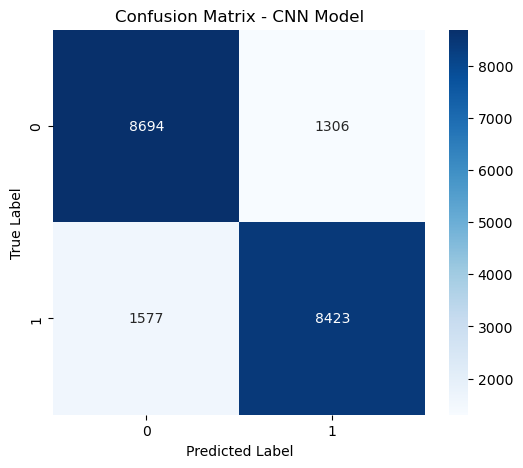

In [ ]:
plt.figure(figsize = (6,5)) # Confusion matrix visualization
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')

plt.title("Confusion Matrix - CNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The baseline CNN model was tested using a dataset of 20,000 images. The results show that the model performs well in classifying images, effectively distinguishing between real and deepfake faces.

The confusion matrix indicates that a high number of both real and fake images were correctly predicted. Additionally, evaluation metrics such as precision, recall, and F1-score reflect a well-balanced performance across both categories.

### **8 - Transfer Learning using MobileNetV2**

In [ ]:
base_model = MobileNetV2(
    weights = 'imagenet',
    include_top = False,
    input_shape = (128,128,3)
)

base_model.trainable = False

Transfer learning was applied using the MobileNetV2 architecture, which is pretrained on the ImageNet dataset. The pretrained layers were utilized as a feature extractor, while additional dense layers were appended to customize the model for deepfake detection.

**Advantages**


Reduced training time


Enhanced feature extraction


Higher accuracy

### **9 - Transfer Learning Model**

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128,activation = 'relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(1,activation = 'sigmoid')(x)

transfer_model = Model(inputs = base_model.input, outputs = predictions)

Additional custom classification layers are placed on top of the pretrained MobileNetV2 model.

### **10 - Compile Transfer Learning Model**

In [ ]:
transfer_model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### **11 - Train Transfer Learning Model**

In [ ]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data = validation_generator,
    epochs = 10
)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2788s 890ms/step - accuracy: 0.6936 - loss: 0.5817 - val_accuracy: 0.7374 - val_loss: 0.5333
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1607s 514ms/step - accuracy: 0.7201 - loss: 0.5499 - val_accuracy: 0.7466 - val_loss: 0.5145
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1829s 574ms/step - accuracy: 0.7283 - loss: 0.5404 - val_accuracy: 0.7363 - val_loss: 0.5257
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1098s 351ms/step - accuracy: 0.7338 - loss: 0.5337 - val_accuracy: 0.7495 - val_loss: 0.5089
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1088s 348ms/step - accuracy: 0.7354 - loss: 0.5297 - val_accuracy: 0.7512 - val_loss: 0.5024
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1090s 349ms/step - accuracy: 0.7406 - loss: 0.5261 - val_accuracy: 0.7625 - val_loss: 0.4889
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1089s 349ms/step - accuracy: 0.7412 - loss: 0.5241 - val_accuracy: 0.7673 - val_loss: 0.4849
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1096s 351ms/s

## **11B - Fine Tuning and Evaluation**

In [ ]:
for layer in base_model.layers[-30:]: # Unfreeze last layers
    layer.trainable = True

In [ ]:
transfer_model.compile(
    optimizer = Adam(learning_rate = 1e-5),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
history_finetune = transfer_model.fit(
    train_generator,
    validation_data = validation_generator,
    epochs = 5
)

Epoch 1/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1287s 408ms/step - accuracy: 0.7089 - loss: 0.6425 - val_accuracy: 0.7728 - val_loss: 0.4847
Epoch 2/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1277s 409ms/step - accuracy: 0.7725 - loss: 0.4819 - val_accuracy: 0.8031 - val_loss: 0.4310
Epoch 3/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1280s 409ms/step - accuracy: 0.7982 - loss: 0.4426 - val_accuracy: 0.8214 - val_loss: 0.3984
Epoch 4/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1274s 408ms/step - accuracy: 0.8143 - loss: 0.4145 - val_accuracy: 0.8366 - val_loss: 0.3731
Epoch 5/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1672s 535ms/step - accuracy: 0.8276 - loss: 0.3885 - val_accuracy: 0.8471 - val_loss: 0.3526


The fine-tuned MobileNetV2 model showed a clear improvement in performance compared to both the baseline CNN and the transfer learning model with frozen layers. By unfreezing the top layers and retraining the network using a lower learning rate, the model was able to better adapt the pretrained features to patterns specific to deepfakes.


The model achieved a validation accuracy of around 84.6%, indicating good generalization and effective learning of relevant features.

In [ ]:
test_loss, test_acc = transfer_model.evaluate(test_generator)

print("Final Test Accuracy:", test_acc)

625/625 ━━━━━━━━━━━━━━━━━━━━ 286s 458ms/step - accuracy: 0.8487 - loss: 0.3487
Final Test Accuracy: 0.8486999869346619


In [ ]:
predictions = transfer_model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int)

cm = confusion_matrix(test_generator.classes, predicted_classes)         # Confusion matrix

print("Confusion Matrix:")
print(cm)

625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 256ms/step
Confusion Matrix:
[[8558 1442]
 [1584 8416]]


In [ ]:
print("Classification Report:")
print(classification_report(test_generator.classes, predicted_classes))  # Classification report

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85     10000
           1       0.85      0.84      0.85     10000

    accuracy                           0.85     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.85      0.85      0.85     20000



### **12 - Finalizing and Preparing for Deployment**

In [ ]:
transfer_model.save("deepfake_final_model.h5") # Saving the model

In [ ]:
model = load_model("deepfake_final_model.h5") # Test loading
print("Model loaded successfully")

Model loaded successfully


In [ ]:
def predict_image(image_path): # Single image prediction

    img = load_img(image_path, target_size = (128,128))
    img = img_to_array(img) / 255.0

    img = np.expand_dims(img, axis = 0)

    prediction = model.predict(img)[0][0]

    if prediction > 0.5:
        label = "Real"
    else:
        label = "Fake"

    return label, prediction

In [ ]:
test_image = r"D:\Data Science Entri App\Data Science Final Project\Dataset\archive\real_vs_fake\real-vs-fake\test\real\00167.jpg"

label, confidence = predict_image(test_image)

print("Prediction:", label)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
Prediction: Real
Confidence: 0.95977837


The fine-tuned MobileNetV2 model was chosen as the final model because it outperformed both the baseline CNN and the transfer learning model with frozen layers. It exhibited strong generalization ability and achieved the highest validation accuracy among all models.

The trained model was then saved and made ready for deployment in a real-time prediction system.

## **Final Phase - Deployment**

In [ ]:
model.save_weights("deepfake.weights.h5") # For flask deployment

During the deployment phase, an error was encountered while loading the trained model using the standard load_model() function. The error was caused due to incompatibility between different versions of Keras and TensorFlow, specifically related to unsupported configuration parameters such as quantization_config.

To resolve this issue, instead of loading the entire model file, the model architecture was reconstructed manually in the deployment script. The trained parameters were then loaded separately using the model.save_weights() and model.load_weights() approach.

The model weights were saved using: model.save_weights("deepfake.weights.h5") (above cell)

and later loaded in the Flask application after rebuilding the same architecture: model.load_weights("deepfake.weights.h5") (app.py)

This method ensures compatibility across different environments by avoiding dependency on serialized model configurations, thereby enabling successful deployment of the deep learning model.